# Conversion Funnel Analysis


This notebook analyzes the customer conversion funnel to identify drop-off points and optimize the user journey from browsing to purchase.

Key goals:
- Measure conversion rates at each stage
- Identify bottlenecks in the purchase process
- Quantify the impact of cart abandonment
- Analyze funnel performance across user segments

## Funnel Stages
funnel_stages = ["Session", "Product View", "Add to Cart", "Purchase"]


In [5]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#loading the dataset

customers = pd.read_csv('../data/raw/customers.csv')
sessions = pd.read_csv('../data/raw/sessions.csv')
cart = pd.read_csv('../data/raw/cart_events.csv')
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')

In [16]:
# Unique users at each stage
total_sessions   = sessions['session_id'].nunique()
cart_sessions    = cart['session_id'].nunique()
order_sessions   = orders['session_id'].nunique()


# Funnel KPI Table

In [22]:
funnel_df = pd.DataFrame({
    "Stage": ["Sessions", "Add to Cart", "Orders"],
    "Users": [total_sessions, cart_sessions, order_sessions]
})

# Conversion rate relative to total sessions
funnel_df["Conversion Rate"] = funnel_df["Users"] / total_sessions

# Drop-off % between consecutive stages
funnel_df["Drop-off %"] = 1 - (funnel_df["Users"] / funnel_df["Users"].shift(1))
funnel_df["Drop-off %"] = funnel_df["Drop-off %"].fillna(0)


funnel_df

,Stage,Users,Conversion Rate,Drop-off %
0,Sessions,12474,1.000000,0.000000
1,Add to Cart,2605,0.208834,0.791166
2,Orders,1025,0.082171,0.606526


# Funnel Visualization

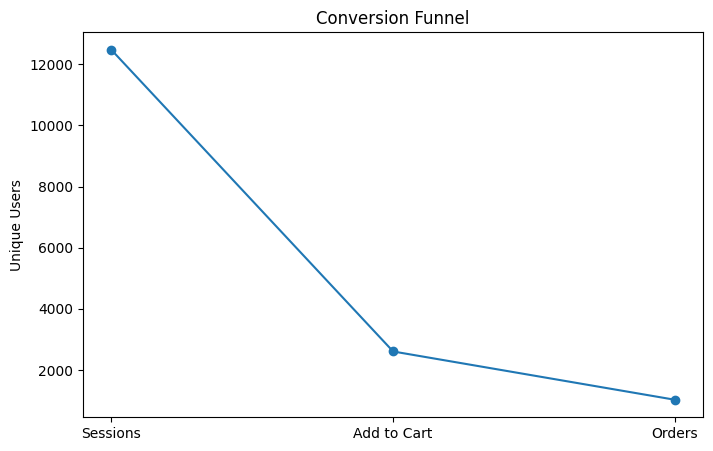

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(funnel_df["Stage"], funnel_df["Users"], marker='o')
plt.title("Conversion Funnel")
plt.ylabel("Unique Users")
plt.show()


# Cart Abandonment Analysis

Cart Abandonment Analysis

In [25]:
cart_abandonment_rate = 1 - (order_sessions / cart_sessions)
print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2%}")


Cart Abandonment Rate: 60.65%


# Funnel by Device

In [26]:
# Merge sessions with orders
sessions_orders = sessions.merge(
    orders[['session_id']], on='session_id', how='left', indicator=True
)
sessions_orders['converted'] = (sessions_orders['_merge'] == 'both').astype(int)

# Funnel by device & customer type
segment_funnel = sessions_orders.groupby(['device','customer_type'])['converted'].mean().reset_index()


KeyError: 'customer_type'

# Funnel by Traffic Source

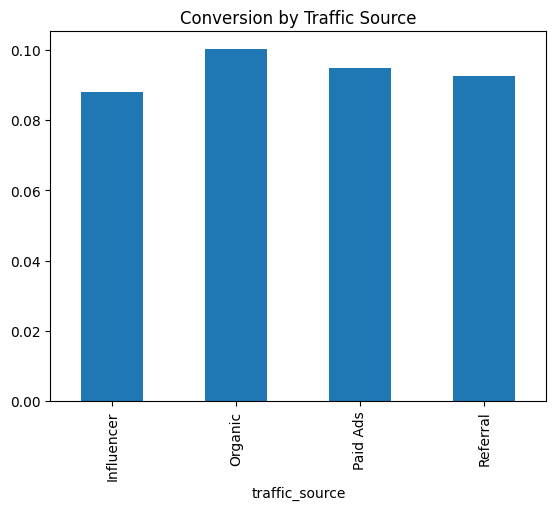

In [11]:
traffic_conversion = sessions_orders.groupby('traffic_source')['converted'].mean()

traffic_conversion.plot(kind='bar')
plt.title("Conversion by Traffic Source")
plt.show()

# Time-Based Funnel

In [27]:
sessions['session_date'] = pd.to_datetime(sessions['session_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Daily
daily_sessions = sessions.groupby('session_date')['session_id'].nunique()
daily_orders   = orders.groupby('order_date')['order_id'].nunique()
daily_conversion = daily_orders / daily_sessions

# Weekly
weekly_sessions = sessions.groupby(pd.Grouper(key='session_date', freq='W'))['session_id'].nunique()
weekly_orders   = orders.groupby(pd.Grouper(key='order_date', freq='W'))['order_id'].nunique()
weekly_conversion = weekly_orders / weekly_sessions


# Conversion Drivers (Behavior Analysis)

In [28]:
sessions['converted'] = sessions['session_id'].isin(orders['session_id']).astype(int)

sessions.groupby('converted')[['pages_viewed','session_duration','cart_size']].mean()


KeyError: "Columns not found: 'cart_size'"

# ML MODEL

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Encode device type
sessions['device_encoded'] = sessions['device'].astype('category').cat.codes

features = sessions[['pages_viewed','session_duration','cart_size','device_encoded']]
target   = sessions['converted']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))


KeyError: "['cart_size'] not in index"